In [144]:
import pandas as pd
import matplotlib.pyplot as plt

In [145]:
df = pd.read_csv("generating data full day map.csv")

In [146]:
df

,SensorID,Timestamp,Longitude,Latitude,Temperature,Company
0,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:00:00,55.294056,25.200047,4.016933,FarmFoods
1,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:05:00,55.223897,25.033230,2.555643,FarmFoods
2,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:10:00,55.595845,25.466385,5.899867,FarmFoods
3,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:15:00,55.140233,24.928933,4.730704,FarmFoods
4,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:20:00,55.610173,25.350872,-6.284973,FarmFoods
...,...,...,...,...,...,...
287995,f919766a-d18f-4bce-b41a-8275e8a082db,2024-09-04 14:35:00,55.573413,25.292014,6.575778,FruitKing
287996,f919766a-d18f-4bce-b41a-8275e8a082db,2024-09-04 14:40:00,55.250756,25.025731,7.625812,FruitKing
287997,f919766a-d18f-4bce-b41a-8275e8a082db,2024-09-04 14:45:00,55.528352,25.222621,6.174583,FruitKing
287998,f919766a-d18f-4bce-b41a-8275e8a082db,2024-09-04 14:50:00,55.054182,24.943848,8.912007,FruitKing


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   SensorID     288000 non-null  object 
 1   Timestamp    288000 non-null  object 
 2   Longitude    288000 non-null  float64
 3   Latitude     288000 non-null  float64
 4   Temperature  288000 non-null  float64
 5   Company      288000 non-null  object 
dtypes: float64(3), object(3)
memory usage: 13.2+ MB


In [148]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# df['Minute'] = df['Timestamp'].dt.minute
# df['Hour'] = df['Timestamp'].dt.hour
# df['Day'] = df['Timestamp'].dt.day
# #df['Month'] = df['Timestamp'].dt.month

In [149]:
df.describe()

,Longitude,Latitude,Temperature
count,288000.000000,288000.000000,288000.000000
mean,55.154874,24.979446,5.467547
std,0.383420,0.395409,4.169749
min,54.313913,24.244629,-9.997826
25%,54.713742,24.478343,2.996561
50%,55.273584,25.113382,5.498352
75%,55.466094,25.291582,7.995664
max,55.680171,25.602414,19.999437


In [150]:
# Get the first sensor ID from the dataset
first_sensor_id = df['SensorID'].unique()[0]  # Retrieve the first sensor's ID

# Filter the data to include only rows corresponding to the first sensor
df_first_sensor = df[df['SensorID'] == first_sensor_id]

# Display the filtered data for the first sensor
df_first_sensor


,SensorID,Timestamp,Longitude,Latitude,Temperature,Company
0,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:00:00,55.294056,25.200047,4.016933,FarmFoods
1,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:05:00,55.223897,25.033230,2.555643,FarmFoods
2,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:10:00,55.595845,25.466385,5.899867,FarmFoods
3,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:15:00,55.140233,24.928933,4.730704,FarmFoods
4,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-03 15:20:00,55.610173,25.350872,-6.284973,FarmFoods
...,...,...,...,...,...,...
283,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-04 14:35:00,54.483361,24.290489,5.002680,FarmFoods
284,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-04 14:40:00,55.434466,25.212372,5.563608,FarmFoods
285,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-04 14:45:00,55.268021,25.228219,8.470876,FarmFoods
286,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,2024-09-04 14:50:00,55.541168,25.535089,2.778327,FarmFoods


In [151]:
df_first_sensor.isnull().sum()

SensorID       0
Timestamp      0
Longitude      0
Latitude       0
Temperature    0
Company        0
dtype: int64

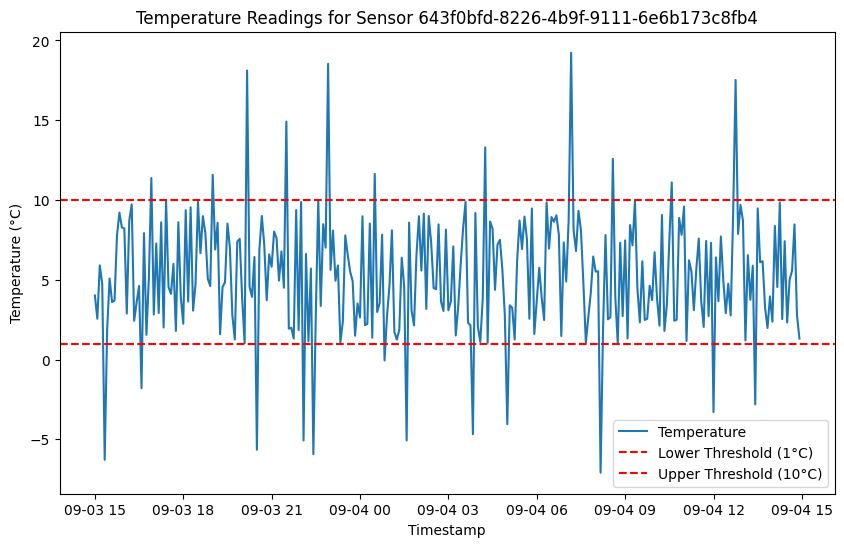

In [135]:
import matplotlib.pyplot as plt

# Plot the temperature readings over time
plt.figure(figsize=(10, 6))
plt.plot(df_first_sensor['Timestamp'], df_first_sensor['Temperature'], label='Temperature')
plt.axhline(1, color='r', linestyle='--', label='Lower Threshold (1°C)')
plt.axhline(10, color='r', linestyle='--', label='Upper Threshold (10°C)')
plt.title(f'Temperature Readings for Sensor {first_sensor_id}')
plt.xlabel('Timestamp')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


C:\Users\nabee\AppData\Roaming\Python\Python38\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


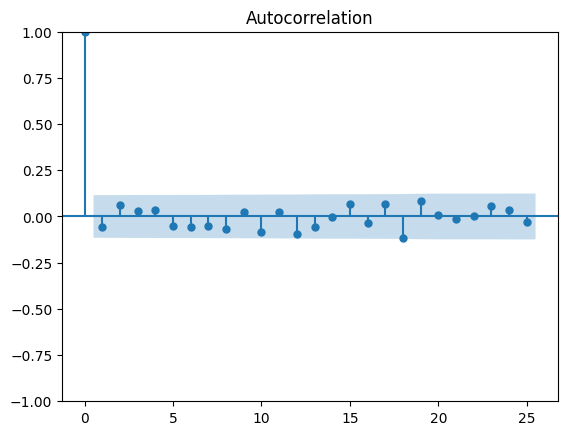

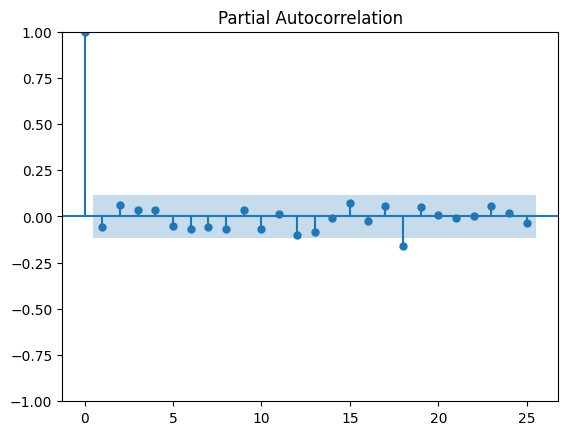

In [115]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_first_sensor['Temperature'])
plot_pacf(df_first_sensor['Temperature'])
plt.show()


Rolling Mean and Rolling Standard Deviation (Std) are important tools in time series analysis that help to understand the trends and variability in your data over a specified window of time. 
#### Interpreting the Results
- Temperature vs. Rolling Mean: Observe how the actual temperature data deviates from the rolling mean. Large deviations might indicate anomalies or significant changes.
- Rolling Mean vs. Rolling Std Dev: Analyze how the variability changes over time. High variability periods can be visually linked to sudden changes in the rolling mean or specific events.

C:\Users\nabee\AppData\Local\Temp\ipykernel_8712\2753082426.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_sensor['Rolling_Mean'] = df_first_sensor['Temperature'].rolling(window=24).mean()
C:\Users\nabee\AppData\Local\Temp\ipykernel_8712\2753082426.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_sensor['Rolling_Std'] = df_first_sensor['Temperature'].rolling(window=24).std()


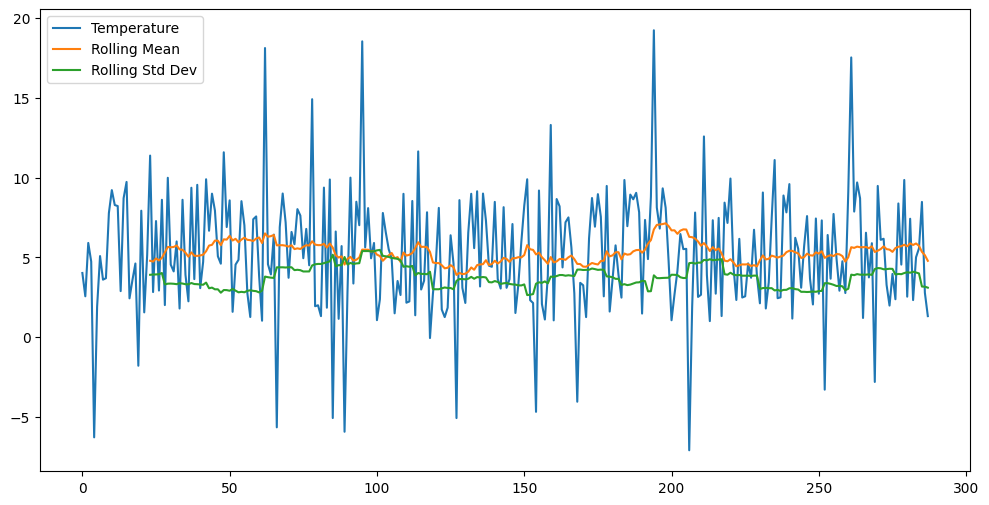

In [98]:
df_first_sensor['Rolling_Mean'] = df_first_sensor['Temperature'].rolling(window=24).mean()
df_first_sensor['Rolling_Std'] = df_first_sensor['Temperature'].rolling(window=24).std()

plt.figure(figsize=(12, 6))
plt.plot(df_first_sensor.index, df_first_sensor['Temperature'], label='Temperature')
plt.plot(df_first_sensor.index, df_first_sensor['Rolling_Mean'], label='Rolling Mean')
plt.plot(df_first_sensor.index, df_first_sensor['Rolling_Std'], label='Rolling Std Dev')
plt.legend()
plt.show()

del df_first_sensor['Rolling_Mean']
del df_first_sensor['Rolling_Std']

In [99]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_first_sensor['Temperature'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -17.867169772246807
p-value: 3.0374332483141437e-30


In [100]:
from statsmodels.tsa.stattools import kpss

result = kpss(df_first_sensor['Temperature'], regression='c')
print('KPSS Statistic:', result[0])
print('p-value:', result[1])


KPSS Statistic: 0.0356378268760828
p-value: 0.1


C:\Users\nabee\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


- A stationary time series has a constant mean, variance, and autocovariance over time. Most models assume the data is stationary.


- Both the ADF and KPSS test results suggest that your time series data is likely stationary. Specifically:

- The ADF test results strongly support stationarity because the p-value is extremely small, far below the usual significance level of 0.05.
- The KPSS test also supports stationarity, as its p-value is greater than 0.05.

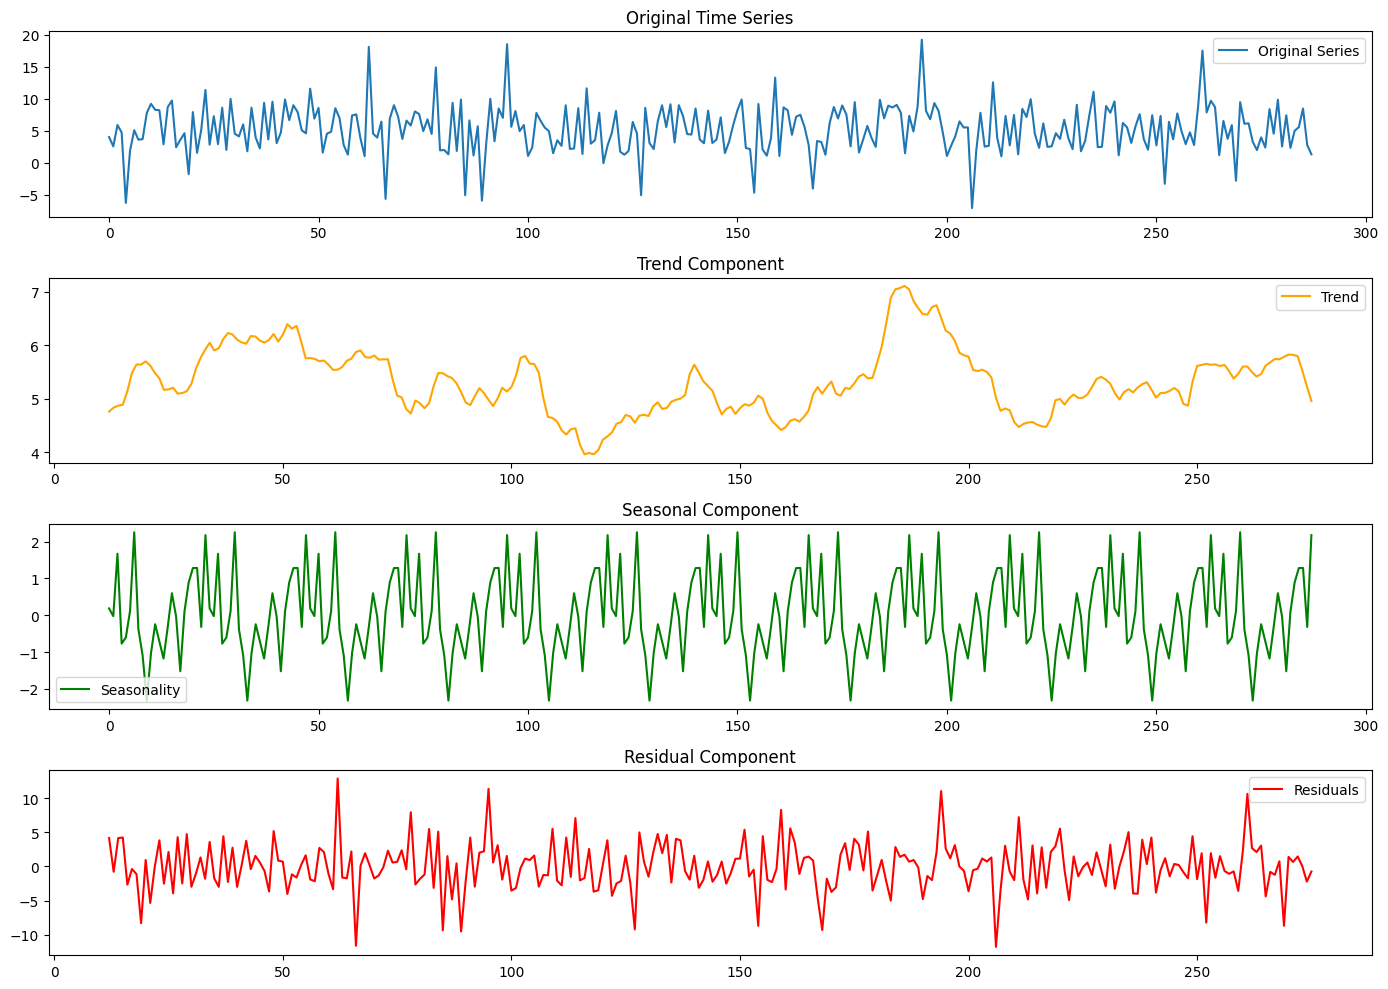

In [101]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform STL decomposition
decomposition = seasonal_decompose(df_first_sensor['Temperature'], model='additive', period=24)

# Extract the components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot the decomposed components
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(df_first_sensor['Temperature'], label='Original Series')
plt.title('Original Time Series')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='orange')
plt.title('Trend Component')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.title('Seasonal Component')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals', color='red')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()


### Explanation of Each Plot:
- Original Time Series:

- - The plot of your original temperature data to give a context of the full time series.
Trend Component:

- - Shows the long-term increase or decrease in the data. It smooths out short-term fluctuations and highlights the overall direction.
- Seasonal Component:

- - Displays the repeating patterns or cycles within the data. For example, daily or weekly cycles in temperature.
- Residual Component:

- - Represents the noise or random variations after removing trend and seasonality. This component shows what is left over that isn’t explained by the trend or seasonality.


### **When to Use Each Technique:**

- **Resampling:** Use when you need to analyze data at a different frequency or smooth out high-frequency noise.
- **Handling Missing Data:** Necessary when there are gaps in your data that could affect the quality of your analysis.
- **Detrending:** Use when you want to focus on seasonal or cyclic patterns without the influence of long-term trends.
- **Deseasonalizing:** Useful when you need to remove seasonal effects to better understand and model the underlying trends.
- **Log Transformation:** Apply when variance is increasing or decreasing exponentially, or if the data spans several orders of magnitude.

### **Choosing the Right Method:**

- **Visual Inspection:** Start with visualizing your data to understand the presence of trends, seasonality, and missing values.
- **Statistical Tests:** Use statistical tests and plots (like rolling statistics) to assess the need for transformations or preprocessing.
- **Domain Knowledge:** Consider domain-specific characteristics of your data when choosing preprocessing methods.

By applying these preprocessing steps, you prepare your time series data for accurate modeling and analysis, leading to more reliable and actionable insights.

In [152]:
df_first_sensor.set_index('Timestamp', inplace=True)

In [153]:
df_first_sensor

,SensorID,Longitude,Latitude,Temperature,Company
Timestamp,,,,,
2024-09-03 15:00:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,55.294056,25.200047,4.016933,FarmFoods
2024-09-03 15:05:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,55.223897,25.033230,2.555643,FarmFoods
2024-09-03 15:10:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,55.595845,25.466385,5.899867,FarmFoods
2024-09-03 15:15:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,55.140233,24.928933,4.730704,FarmFoods
2024-09-03 15:20:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,55.610173,25.350872,-6.284973,FarmFoods
...,...,...,...,...,...
2024-09-04 14:35:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,54.483361,24.290489,5.002680,FarmFoods
2024-09-04 14:40:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,55.434466,25.212372,5.563608,FarmFoods
2024-09-04 14:45:00,643f0bfd-8226-4b9f-9111-6e6b173c8fb4,55.268021,25.228219,8.470876,FarmFoods


In [154]:
# Drop the first column by index position (0 is the first column)
first_column_name = df_first_sensor.columns[0]
df_first_sensor.drop(columns=[first_column_name], inplace=True)
df_first_sensor

C:\Users\nabee\AppData\Local\Temp\ipykernel_8712\2549971017.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_sensor.drop(columns=[first_column_name], inplace=True)


,Longitude,Latitude,Temperature,Company
Timestamp,,,,
2024-09-03 15:00:00,55.294056,25.200047,4.016933,FarmFoods
2024-09-03 15:05:00,55.223897,25.033230,2.555643,FarmFoods
2024-09-03 15:10:00,55.595845,25.466385,5.899867,FarmFoods
2024-09-03 15:15:00,55.140233,24.928933,4.730704,FarmFoods
2024-09-03 15:20:00,55.610173,25.350872,-6.284973,FarmFoods
...,...,...,...,...
2024-09-04 14:35:00,54.483361,24.290489,5.002680,FarmFoods
2024-09-04 14:40:00,55.434466,25.212372,5.563608,FarmFoods
2024-09-04 14:45:00,55.268021,25.228219,8.470876,FarmFoods


In [155]:
# Drop the first column by its name
df_first_sensor.drop(columns=['Company'], inplace=True)

# Verify the changes
print(df_first_sensor.head())

                     Longitude   Latitude  Temperature
Timestamp                                             
2024-09-03 15:00:00  55.294056  25.200047     4.016933
2024-09-03 15:05:00  55.223897  25.033230     2.555643
2024-09-03 15:10:00  55.595845  25.466385     5.899867
2024-09-03 15:15:00  55.140233  24.928933     4.730704
2024-09-03 15:20:00  55.610173  25.350872    -6.284973


C:\Users\nabee\AppData\Local\Temp\ipykernel_8712\66511393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_first_sensor.drop(columns=['Company'], inplace=True)


In [156]:
from sklearn.model_selection import train_test_split

X = df_first_sensor.drop(columns=['Temperature'])  # Input features
y = df_first_sensor['Temperature']  # Target variable
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [157]:
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (230, 2)
Shape of y_train: (230,)
Shape of X_test: (58, 2)
Shape of y_test: (58,)


In [158]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with original column names
X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test= pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [159]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


#Transform the Training Data with Polynomial Features
poly_regr = PolynomialFeatures(degree=3)
X_poly_train = poly_regr.fit_transform(X_train )

#Train the Polynomial Regression Model
regressor = LinearRegression()
regressor.fit(X_poly_train, y_train)

# Transform the Testing Data with Polynomial Features
X_poly_test = poly_regr.transform(X_test)

# Predict
y_pred = regressor.predict(X_poly_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R2) Score:", r2)
# Mean Squared Error (MSE): 11.399336534872571
# R-squared (R2) Score: -0.12070447774052351

# Mean Squared Error (MSE): 18.49459161805078
# R-squared (R2) Score: -0.8182612274779695

Mean Squared Error (MSE): 11.399336534872571
R-squared (R2) Score: -0.12070447774052351
